In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("LoanIQ environment initialized successfully.")

LoanIQ environment initialized successfully.


In [3]:
DATA_PATH = Path("../data/Loan.csv")

df = pd.read_csv(DATA_PATH)

In [4]:
print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape}")

Dataset loaded successfully!
Shape: (20000, 36)


In [5]:
df.head(2)

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,2,Own,183,0.354418,1,2,0.358336,0,Home,0,29,9,7632,1202,146111,19183,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,1,Mortgage,496,0.087827,5,3,0.330274,0,Debt Consolidation,0,21,9,4627,3460,53204,9595,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             20000 non-null  str    
 1   Age                         20000 non-null  int64  
 2   AnnualIncome                20000 non-null  int64  
 3   CreditScore                 20000 non-null  int64  
 4   EmploymentStatus            20000 non-null  str    
 5   EducationLevel              20000 non-null  str    
 6   Experience                  20000 non-null  int64  
 7   LoanAmount                  20000 non-null  int64  
 8   LoanDuration                20000 non-null  int64  
 9   MaritalStatus               20000 non-null  str    
 10  NumberOfDependents          20000 non-null  int64  
 11  HomeOwnershipStatus         20000 non-null  str    
 12  MonthlyDebtPayments         20000 non-null  int64  
 13  CreditCardUtilizationRate   20000 non-null

In [7]:
df.describe

<bound method NDFrame.describe of       ApplicationDate  Age  AnnualIncome  CreditScore EmploymentStatus  \
0          2018-01-01   45         39948          617         Employed   
1          2018-01-02   38         39709          628         Employed   
2          2018-01-03   47         40724          570         Employed   
3          2018-01-04   58         69084          545         Employed   
4          2018-01-05   37        103264          594         Employed   
...               ...  ...           ...          ...              ...   
19995      2072-09-29   44         30180          587         Employed   
19996      2072-09-30   56         49246          567         Employed   
19997      2072-10-01   44         48958          645         Employed   
19998      2072-10-02   60         41025          560         Employed   
19999      2072-10-03   20         53227          574         Employed   

      EducationLevel  Experience  LoanAmount  LoanDuration MaritalStatus  \
0

In [8]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

Series([], dtype: int64)

In [9]:
df.columns

Index(['ApplicationDate', 'Age', 'AnnualIncome', 'CreditScore',
       'EmploymentStatus', 'EducationLevel', 'Experience', 'LoanAmount',
       'LoanDuration', 'MaritalStatus', 'NumberOfDependents',
       'HomeOwnershipStatus', 'MonthlyDebtPayments',
       'CreditCardUtilizationRate', 'NumberOfOpenCreditLines',
       'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory',
       'LoanPurpose', 'PreviousLoanDefaults', 'PaymentHistory',
       'LengthOfCreditHistory', 'SavingsAccountBalance',
       'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities',
       'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth',
       'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment',
       'TotalDebtToIncomeRatio', 'LoanApproved', 'RiskScore'],
      dtype='str')

In [10]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_summary = missing_summary.sort_values(
    by="Missing %",
    ascending=False
)

missing_summary

,Missing Count,Missing %
ApplicationDate,0,0.0
Age,0,0.0
AnnualIncome,0,0.0
CreditScore,0,0.0
EmploymentStatus,0,0.0
EducationLevel,0,0.0
Experience,0,0.0
LoanAmount,0,0.0
LoanDuration,0,0.0
MaritalStatus,0,0.0


In [11]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count:,}")
print(f"Duplicate percentage: {duplicate_count / len(df) * 100:.2f}%")

Duplicate rows: 0
Duplicate percentage: 0.00%


In [12]:
TARGET = "LoanApproved"

print(f"Target variable: {TARGET}")
print(f"Target data type: {df[TARGET].dtype}")

Target variable: LoanApproved
Target data type: int64


In [13]:
print(df[TARGET].value_counts())

LoanApproved
0    15220
1     4780
Name: count, dtype: int64


In [14]:
target_distribution = (
    df[TARGET]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

target_distribution

LoanApproved
0    76.1
1    23.9
Name: proportion, dtype: float64

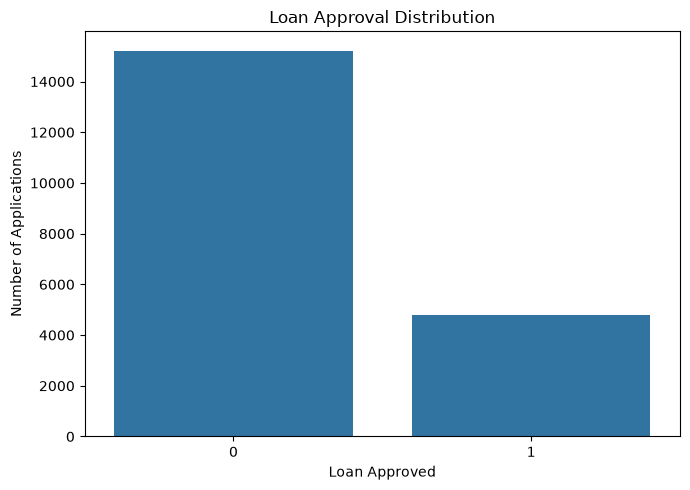

In [15]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x=TARGET)

plt.title("Loan Approval Distribution")
plt.xlabel("Loan Approved")
plt.ylabel("Number of Applications")
plt.tight_layout()
plt.show()

In [16]:
majority_class = df[TARGET].mode()[0]
baseline_accuracy = (df[TARGET] == majority_class).mean()

print(f"Majority class: {majority_class}")
print(f"Baseline accuracy: {baseline_accuracy:.2%}")

Majority class: 0
Baseline accuracy: 76.10%


In [18]:
categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Categorical columns:")
for column in categorical_columns:
    print(f"• {column}")

Categorical columns:
• ApplicationDate
• EmploymentStatus
• EducationLevel
• MaritalStatus
• HomeOwnershipStatus
• LoanPurpose


C:\Users\atanu\AppData\Local\Temp\ipykernel_18908\2714842693.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(


In [19]:
for column in categorical_columns:
    print(f"\n{'=' * 60}")
    print(f"📌 {column}")
    print(f"{'=' * 60}")
    
    approval_rate = (
        df.groupby(column)[TARGET]
        .mean()
        .mul(100)
        .round(2)
        .sort_values(ascending=False)
    )
    
    print(approval_rate)


📌 ApplicationDate
ApplicationDate
2043-11-29    100.0
2040-02-01    100.0
2072-09-04    100.0
2029-08-23    100.0
2036-05-02    100.0
              ...  
2018-01-12      0.0
2018-01-13      0.0
2018-01-14      0.0
2018-01-15      0.0
2065-11-29      0.0
Name: LoanApproved, Length: 20000, dtype: float64

📌 EmploymentStatus
EmploymentStatus
Self-Employed    27.84
Employed         24.00
Unemployed       18.19
Name: LoanApproved, dtype: float64

📌 EducationLevel
EducationLevel
Doctorate      44.03
Master         35.08
Bachelor       26.64
Associate      20.43
High School    14.44
Name: LoanApproved, dtype: float64

📌 MaritalStatus
MaritalStatus
Divorced    24.50
Single      23.94
Married     23.85
Widowed     22.42
Name: LoanApproved, dtype: float64

📌 HomeOwnershipStatus
HomeOwnershipStatus
Mortgage    25.15
Own         24.89
Rent        22.77
Other       20.48
Name: LoanApproved, dtype: float64

📌 LoanPurpose
LoanPurpose
Education             25.30
Auto                  24.27
Home      

In [20]:
numerical_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

numerical_features = [
    column for column in numerical_columns
    if column != TARGET
]

print("Numerical features:")
for column in numerical_features:
    print(f"• {column}")

Numerical features:
• Age
• AnnualIncome
• CreditScore
• Experience
• LoanAmount
• LoanDuration
• NumberOfDependents
• MonthlyDebtPayments
• CreditCardUtilizationRate
• NumberOfOpenCreditLines
• NumberOfCreditInquiries
• DebtToIncomeRatio
• BankruptcyHistory
• PreviousLoanDefaults
• PaymentHistory
• LengthOfCreditHistory
• SavingsAccountBalance
• CheckingAccountBalance
• TotalAssets
• TotalLiabilities
• MonthlyIncome
• UtilityBillsPaymentHistory
• JobTenure
• NetWorth
• BaseInterestRate
• InterestRate
• MonthlyLoanPayment
• TotalDebtToIncomeRatio
• RiskScore


In [21]:
comparison = (
    df.groupby(TARGET)[numerical_features]
    .mean()
    .T
)

comparison

LoanApproved,0,1
Age,38.834034,42.677406
AnnualIncome,45641.460907,102210.551464
CreditScore,567.554205,584.534100
Experience,16.630092,20.365063
LoanAmount,26684.996386,19144.709414
LoanDuration,55.363995,49.895397
NumberOfDependents,1.515966,1.521548
MonthlyDebtPayments,463.783180,424.074059
CreditCardUtilizationRate,0.287318,0.283397
NumberOfOpenCreditLines,3.027989,3.008577


In [22]:
potential_features = [
    "RiskScore",
    "InterestRate",
    "BaseInterestRate",
    "MonthlyLoanPayment",
    "TotalDebtToIncomeRatio"
]

leakage_analysis = (
    df.groupby(TARGET)[potential_features]
    .mean()
    .T
)

leakage_analysis

LoanApproved,0,1
RiskScore,54.106307,40.133389
InterestRate,0.246244,0.216393
BaseInterestRate,0.244045,0.223457
MonthlyLoanPayment,981.268113,689.799237
TotalDebtToIncomeRatio,0.480130,0.153987


In [23]:
leakage_correlation = (
    df[potential_features + [TARGET]]
    .corr()[TARGET]
    .drop(TARGET)
    .sort_values(key=abs, ascending=False)
)

leakage_correlation

RiskScore                -0.766137
TotalDebtToIncomeRatio   -0.410399
InterestRate             -0.301646
BaseInterestRate         -0.247263
MonthlyLoanPayment       -0.184272
Name: LoanApproved, dtype: float64

In [24]:
df[potential_features].corr()

,RiskScore,InterestRate,BaseInterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio
RiskScore,1.000000,0.268203,0.256233,0.115501,0.342643
InterestRate,0.268203,1.000000,0.834557,0.127497,0.131765
BaseInterestRate,0.256233,0.834557,1.000000,0.118030,0.131853
MonthlyLoanPayment,0.115501,0.127497,0.118030,1.000000,0.567842
TotalDebtToIncomeRatio,0.342643,0.131765,0.131853,0.567842,1.000000


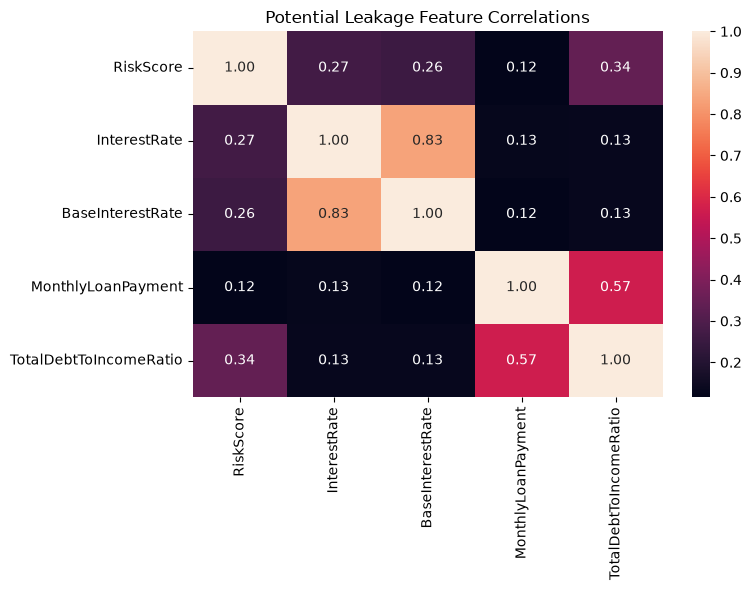

In [25]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df[potential_features].corr(),
    annot=True,
    fmt=".2f"
)

plt.title("Potential Leakage Feature Correlations")
plt.tight_layout()
plt.show()

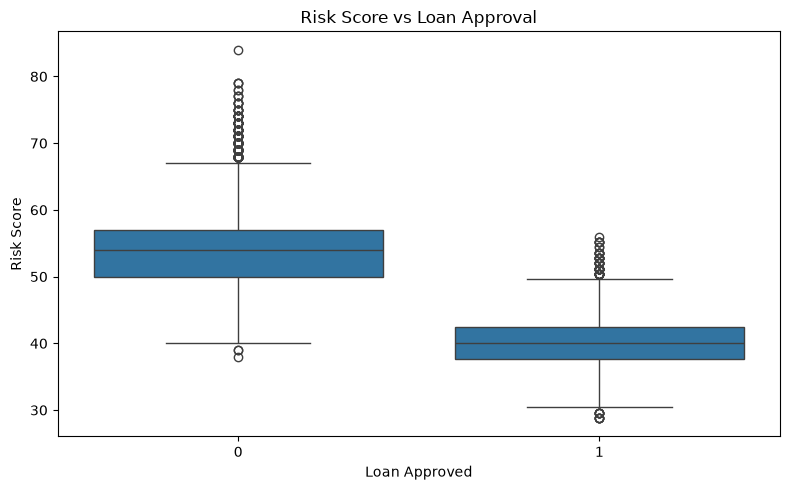

In [26]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x=TARGET,
    y="RiskScore"
)

plt.title("Risk Score vs Loan Approval")
plt.xlabel("Loan Approved")
plt.ylabel("Risk Score")

plt.tight_layout()
plt.show()

In [27]:
df.groupby(TARGET)["RiskScore"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

,count,mean,median,std,min,max
LoanApproved,,,,,,
0,15220,54.106307,54.0,5.301985,38.0,84.0
1,4780,40.133389,40.0,3.879725,28.8,56.0


### During exploratory analysis, several features were identified as potential target proxies or deterministic derivatives of other variables.

- RiskScore shows a very strong relationship with LoanApproved and is treated as a potential target proxy.
- MonthlyLoanPayment is mathematically derived from LoanAmount, LoanDuration, and InterestRate.
- TotalDebtToIncomeRatio is mathematically derived from MonthlyDebtPayments, MonthlyLoanPayment, and MonthlyIncome.
- InterestRate may represent information determined during the lending process and may not be available at the initial application stage.

To maintain a realistic application-time prediction scenario and reduce redundancy, these variables will not be used as primary model features.

The final feature set will be determined after completing EDA and validating feature availability.

In [28]:
excluded_features = [
    "RiskScore",
    "InterestRate",
    "MonthlyLoanPayment",
    "TotalDebtToIncomeRatio"
]

print("Excluded features:")
for feature in excluded_features:
    print(f"• {feature}")

Excluded features:
• RiskScore
• InterestRate
• MonthlyLoanPayment
• TotalDebtToIncomeRatio


In [29]:
candidate_features = [
    column for column in df.columns
    if column not in excluded_features + [TARGET]
]

print(f"Number of candidate features: {len(candidate_features)}")

for feature in candidate_features:
    print(f"• {feature}")

Number of candidate features: 31
• ApplicationDate
• Age
• AnnualIncome
• CreditScore
• EmploymentStatus
• EducationLevel
• Experience
• LoanAmount
• LoanDuration
• MaritalStatus
• NumberOfDependents
• HomeOwnershipStatus
• MonthlyDebtPayments
• CreditCardUtilizationRate
• NumberOfOpenCreditLines
• NumberOfCreditInquiries
• DebtToIncomeRatio
• BankruptcyHistory
• LoanPurpose
• PreviousLoanDefaults
• PaymentHistory
• LengthOfCreditHistory
• SavingsAccountBalance
• CheckingAccountBalance
• TotalAssets
• TotalLiabilities
• MonthlyIncome
• UtilityBillsPaymentHistory
• JobTenure
• NetWorth
• BaseInterestRate


In [30]:
print(df["ApplicationDate"].head())
print()
print(df["ApplicationDate"].dtype)

0    2018-01-01
1    2018-01-02
2    2018-01-03
3    2018-01-04
4    2018-01-05
Name: ApplicationDate, dtype: str

str


In [31]:
df["ApplicationDate"] = pd.to_datetime(df["ApplicationDate"])

print("Date range:")
print("Start:", df["ApplicationDate"].min())
print("End  :", df["ApplicationDate"].max())

Date range:
Start: 2018-01-01 00:00:00
End  : 2072-10-03 00:00:00


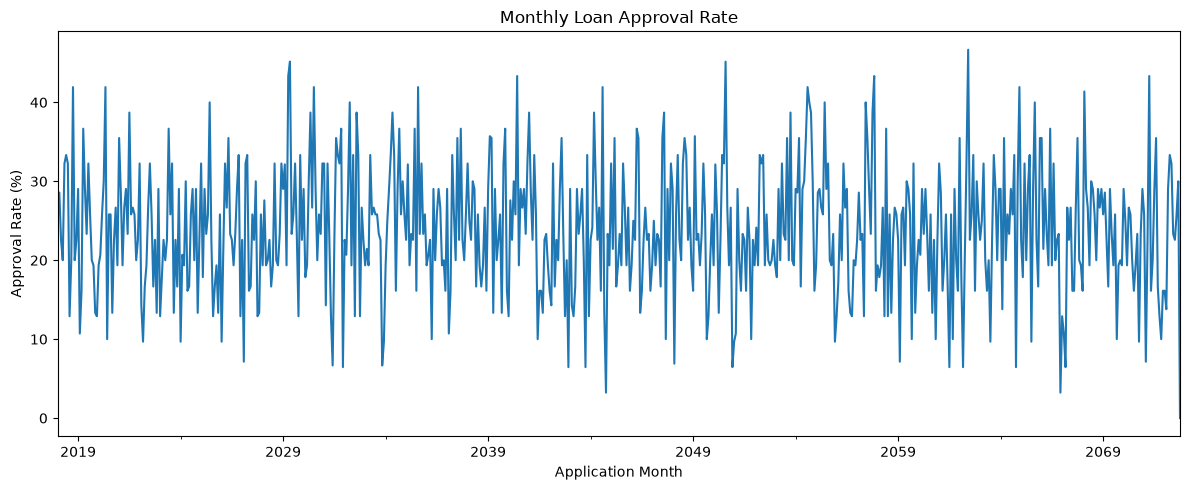

In [32]:
monthly_approval = (
    df.set_index("ApplicationDate")
      .resample("ME")[TARGET]
      .mean()
      .mul(100)
)

monthly_approval.plot(figsize=(12, 5))

plt.title("Monthly Loan Approval Rate")
plt.xlabel("Application Month")
plt.ylabel("Approval Rate (%)")
plt.tight_layout()
plt.show()